In [99]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import multiprocessing as mp
from pathlib import Path
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, balanced_accuracy_score, f1_score, matthews_corrcoef, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


In [107]:
TCGA_SAMPLES = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/runAll.sh.samples"
CGI_BED = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/cgi.bed"
PMD_PATH = Path("/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/results/05_tcga_classification_analysis/segmentation/methylseg")
HG38_PATH = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/hg38.chrom.sizes"
CENTROMERE_PATH = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/centromere.bed"
GAP_PATH = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/gap.bed"
RANDOM_SEED = 42
MAX_SPLIT_WORKERS = 80
_RANDOM_REGION_REFERENCE_CACHE = None
_FEATURE_CLASSIFICATION_WORKER_STATE = {}
CANNONICAL_CHROMOSOMES = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
METH_REF = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/parse450K.pl.order.lookup"

In [102]:
def load_tcga_samples(cancer_type = None):
    """
    Load TCGA samples for a given cancer type.

    Parameters:
    cancer_type (str): The type of cancer to load samples for. If None, load all samples.

    Returns:
    pd.DataFrame: A DataFrame containing the TCGA samples.
    """

    samples_info_path = pd.read_csv(TCGA_SAMPLES, sep='\t')

    if cancer_type:
        tcga_samples = samples_info_path[samples_info_path['project_id'] == cancer_type]
    else:
        tcga_samples = samples_info_path

    return tcga_samples

def load_methylation_data(samples_info):
    """
    Load methylation data for each sample.

    Parameters
    ----------
    samples_info : pd.DataFrame
        Must contain:
        - sample
        - methylation_file

    Returns
    -------
    pd.DataFrame
        CpG coordinates followed by one methylation column per sample.
    """

    meth_ref = pd.read_csv(METH_REF, sep="\t")

    required_ref_columns = ["CpG_chrm", "CpG_beg", "CpG_end"]
    missing_ref_columns = [
        column
        for column in required_ref_columns
        if column not in meth_ref.columns
    ]

    if missing_ref_columns:
        raise ValueError(
            f"Methylation reference is missing columns: {missing_ref_columns}"
        )

    meth_vals = {}

    for _, row in samples_info.iterrows():
        sample_id = row["sample"]
        meth_file = row["methylation_file"]

        meth = np.load(meth_file).astype(float)

        # 255 represents a missing methylation value.
        meth[meth == 255] = np.nan

        # Ensure each methylation array matches the CpG reference.
        if len(meth) != len(meth_ref):
            raise ValueError(
                f"Length mismatch for sample {sample_id}: "
                f"{len(meth)} methylation values but "
                f"{len(meth_ref)} CpGs in METH_REF."
            )

        meth_vals[sample_id] = meth

    meth_data_df = pd.DataFrame(meth_vals)

    coordinate_df = (
        meth_ref[required_ref_columns]
        .reset_index(drop=True)
        .copy()
    )

    meth_data_df = meth_data_df.reset_index(drop=True)

    result = pd.concat(
        [coordinate_df, meth_data_df],
        axis=1,
    )

    return result

def load_pmds_per_sample(samples_info):
    """
    Load PMDs (Partially Methylated Domains) for each sample.

    Parameters:
    samples_info (pd.DataFrame): A DataFrame containing sample information.

    Returns:
    dict: A dictionary where keys are sample IDs and values are DataFrames of PMDs.
    """

    pmds_per_sample = {}

    for _, row in samples_info.iterrows():
        sample_id = row['sample']
        pmds_file_path = PMD_PATH / sample_id / 'out' / 'hm450k' / 'summary_files' / 'segments_cleaned_PMD.bed'
        pmds_data = pd.read_csv(
            pmds_file_path,
            sep='\t',
            header=None,
            names=['chrom', 'start', 'end', 'type'],
        )
        pmds_per_sample[sample_id] = pmds_data

    return pmds_per_sample


def _normalize_regions(region_df):
    if region_df is None or region_df.empty:
        return pd.DataFrame(columns=['chrom', 'start', 'end', 'length'])

    if 'chrom' in region_df.columns:
        chrom_col = 'chrom'
    elif 'chr' in region_df.columns:
        chrom_col = 'chr'
    elif "CpG_chrm" in region_df.columns:
        chrom_col = "CpG_chrm"
    else:
        raise ValueError("Region dataframe must contain either a 'chrom' or 'chr' column.")

    normalized = region_df.rename(columns={chrom_col: 'chrom'})[['chrom', 'start', 'end']].copy()
    normalized['chrom'] = normalized['chrom'].astype(str)
    normalized['start'] = pd.to_numeric(normalized['start'], errors='coerce')
    normalized['end'] = pd.to_numeric(normalized['end'], errors='coerce')
    normalized = normalized.dropna(subset=['start', 'end']).copy()
    normalized['start'] = normalized['start'].astype(int)
    normalized['end'] = normalized['end'].astype(int)
    normalized['length'] = normalized['end'] - normalized['start']
    return normalized.reset_index(drop=True)


def _merge_intervals(interval_df):
    intervals = _normalize_regions(interval_df)
    if intervals.empty:
        return intervals

    intervals = intervals.sort_values(['chrom', 'start', 'end']).reset_index(drop=True)
    merged_rows = []

    for chrom, chrom_df in intervals.groupby('chrom', sort=False):
        current_start = int(chrom_df.iloc[0]['start'])
        current_end = int(chrom_df.iloc[0]['end'])

        for row in chrom_df.iloc[1:].itertuples(index=False):
            start = int(row.start)
            end = int(row.end)
            if start <= current_end:
                current_end = max(current_end, end)
            else:
                merged_rows.append({'chrom': chrom, 'start': current_start, 'end': current_end})
                current_start = start
                current_end = end

        merged_rows.append({'chrom': chrom, 'start': current_start, 'end': current_end})

    merged_df = pd.DataFrame(merged_rows, columns=['chrom', 'start', 'end'])
    merged_df['length'] = merged_df['end'] - merged_df['start']
    return merged_df.reset_index(drop=True)

def _load_random_region_reference_data():
    global _RANDOM_REGION_REFERENCE_CACHE

    if _RANDOM_REGION_REFERENCE_CACHE is None:
        centromeres = pd.read_csv(
            CENTROMERE_PATH,
            sep='\t',
            header=None,
            usecols=[0, 1, 2],
            names=['chrom', 'start', 'end'],
        )
        gaps = pd.read_csv(
            GAP_PATH,
            sep='\t',
            usecols=['chrom', 'chromStart', 'chromEnd', 'type'],
        )
        telomeres = gaps.loc[
            gaps['type'].astype(str).eq('telomere'),
            ['chrom', 'chromStart', 'chromEnd'],
        ].rename(columns={'chromStart': 'start', 'chromEnd': 'end'})
        forbidden_regions = _merge_intervals(pd.concat([centromeres, telomeres], ignore_index=True))

        chromosome_sizes = pd.read_csv(
            HG38_PATH,
            sep='\t',
            header=None,
            names=['chrom', 'size'],
        )
        chromosome_sizes['chrom'] = chromosome_sizes['chrom'].astype(str)
        chromosome_sizes['size'] = pd.to_numeric(chromosome_sizes['size'], errors='coerce')
        chromosome_sizes = chromosome_sizes.dropna(subset=['size']).copy()
        chromosome_sizes['size'] = chromosome_sizes['size'].astype(int)

        _RANDOM_REGION_REFERENCE_CACHE = (forbidden_regions, chromosome_sizes)

    return _RANDOM_REGION_REFERENCE_CACHE


def _build_allowed_region_pool(excluded_regions=None, min_length_bp=1):
    forbidden_regions, chromosome_sizes = _load_random_region_reference_data()
    excluded = _normalize_regions(excluded_regions)
    min_length_bp = max(1, int(min_length_bp))
    if not excluded.empty:
        forbidden_regions = _merge_intervals(
            pd.concat(
                [
                    forbidden_regions[['chrom', 'start', 'end']],
                    excluded[['chrom', 'start', 'end']],
                ],
                ignore_index=True,
            )
        )
    forbidden_by_chrom = {
        chrom: chrom_df.reset_index(drop=True)
        for chrom, chrom_df in forbidden_regions.groupby('chrom', sort=False)
    }

    allowed_rows = []
    for row in chromosome_sizes.itertuples(index=False):
        chrom = str(row.chrom)
        chrom_size = int(row.size)
        cursor = 0
        chrom_forbidden = forbidden_by_chrom.get(chrom)

        if chrom_forbidden is not None and not chrom_forbidden.empty:
            for interval in chrom_forbidden.itertuples(index=False):
                start = max(0, int(interval.start))
                end = min(chrom_size, int(interval.end))
                if start > cursor:
                    allowed_rows.append({'chrom': chrom, 'start': cursor, 'end': start})
                cursor = max(cursor, end)

        if cursor < chrom_size:
            allowed_rows.append({'chrom': chrom, 'start': cursor, 'end': chrom_size})

    allowed_pool = _normalize_regions(pd.DataFrame(allowed_rows, columns=['chrom', 'start', 'end']))
    return allowed_pool.loc[allowed_pool['length'] >= min_length_bp].reset_index(drop=True)


def _subtract_interval_from_pool(pool_df, chrom, used_start, used_end):
    if pool_df.empty:
        return pool_df.copy()

    kept_rows = []
    for row in pool_df.itertuples(index=False):
        if row.chrom != chrom or int(row.end) <= used_start or int(row.start) >= used_end:
            kept_rows.append({'chrom': row.chrom, 'start': int(row.start), 'end': int(row.end)})
            continue
        if int(row.start) < used_start:
            kept_rows.append({'chrom': row.chrom, 'start': int(row.start), 'end': int(used_start)})
        if int(row.end) > used_end:
            kept_rows.append({'chrom': row.chrom, 'start': int(used_end), 'end': int(row.end)})

    return _normalize_regions(pd.DataFrame(kept_rows, columns=['chrom', 'start', 'end']))


def collect_all_pmds(pmds_dict, fuzzy_merge_distance=1_000):
    """
    Merge PMDs across samples, allowing nearby regions to collapse together.

    Returns columns:
    chrom, start, end, length, sample_count, samples
    """
    parts = []
    for sample_id, df in pmds_dict.items():
        if df is None or df.empty:
            continue

        part = df[['chrom', 'start', 'end']].copy()
        part['sample_id'] = sample_id
        parts.append(part)

    if not parts:
        return pd.DataFrame(columns=['chrom', 'start', 'end', 'length', 'sample_count', 'samples'])

    all_pmds = (
        pd.concat(parts, ignore_index=True)
        .sort_values(['chrom', 'start', 'end'])
        .reset_index(drop=True)
    )

    merged_rows = []

    for chrom, chrom_df in all_pmds.groupby('chrom', sort=False):
        current_start = None
        current_end = None
        current_samples = set()

        for row in chrom_df.itertuples(index=False):
            start = int(row.start)
            end = int(row.end)
            sample_id = row.sample_id

            if current_start is None:
                current_start = start
                current_end = end
                current_samples = {sample_id}
                continue

            if start <= current_end + fuzzy_merge_distance:
                current_end = max(current_end, end)
                current_samples.add(sample_id)
            else:
                merged_rows.append({
                    'chrom': chrom,
                    'start': current_start,
                    'end': current_end,
                    'length': current_end - current_start,
                    'sample_count': len(current_samples),
                    'samples': sorted(current_samples),
                })
                current_start = start
                current_end = end
                current_samples = {sample_id}

        merged_rows.append({
            'chrom': chrom,
            'start': current_start,
            'end': current_end,
            'length': current_end - current_start,
            'sample_count': len(current_samples),
            'samples': sorted(current_samples),
        })

    return pd.DataFrame(merged_rows)


def load_cgis(filter_to_cannonical=True):
    """
    Load CpG islands (CGIs) data.

    Returns:
    pd.DataFrame: A DataFrame containing the CGI data.
    """

    cgi_data = pd.read_csv(
        CGI_BED,
        sep='\t',
        header=None,
        usecols=[0, 1, 2, 3],
        names=['chrom', 'start', 'end', 'name'],
    )
    cgi_data['length'] = cgi_data['end'] - cgi_data['start']

    if filter_to_cannonical:
        cgi_data = cgi_data[cgi_data['chrom'].isin(CANNONICAL_CHROMOSOMES)].reset_index(drop=True)

    return cgi_data


def pick_recurrent_pmds(all_pmds):
    recurrent_pmds = all_pmds.copy()

    if recurrent_pmds.empty:
        return recurrent_pmds.reset_index(drop=True)

    if "length" not in recurrent_pmds.columns:
        recurrent_pmds["length"] = (
            recurrent_pmds["end"] - recurrent_pmds["start"]
        )

    return (
        recurrent_pmds
        .sort_values(
            ["sample_count", "length"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

def fit_gamma_length_distribution(reference_regions: pd.DataFrame):
    """
    Fit a gamma distribution to observed region lengths.

    Returns a dictionary that can be passed into pick_random_methylation_regions.
    """

    reference = _normalize_regions(reference_regions)
    if reference.empty:
        raise ValueError('reference_regions must contain at least one valid interval.')

    lengths = reference['length'].to_numpy(dtype=float)
    if np.any(lengths <= 0):
        raise ValueError('reference_regions must contain positive interval lengths.')

    shape, loc, scale = stats.gamma.fit(lengths, floc=0)

    return {
        'distribution': 'gamma',
        'shape': float(shape),
        'scale': float(scale),
        'loc': float(loc),
        'min_length': int(np.floor(lengths.min())),
        'max_length': int(np.ceil(lengths.max())),
        'mean_length': float(lengths.mean()),
        'variance': float(lengths.var(ddof=1)) if len(lengths) > 1 else 0.0,
        'n_observations': int(len(lengths)),
    }


def _sample_gamma_lengths(n_regions, length_distribution, rng):
    if length_distribution.get('distribution') != 'gamma':
        raise ValueError('length_distribution must come from fit_gamma_length_distribution().')

    sampled = rng.gamma(
        shape=float(length_distribution['shape']),
        scale=float(length_distribution['scale']),
        size=int(n_regions),
    ) + float(length_distribution.get('loc', 0.0))
    sampled = np.rint(sampled).astype(int)
    sampled = np.clip(
        sampled,
        int(length_distribution['min_length']),
        int(length_distribution['max_length']),
    )
    sampled[sampled < 1] = 1
    return sampled


def _gamma_min_realistic_length(length_distribution):
    if length_distribution.get('distribution') != 'gamma':
        raise ValueError('length_distribution must come from fit_gamma_length_distribution().')

    min_length = stats.gamma.ppf(
        0.25,
        a=float(length_distribution['shape']),
        loc=float(length_distribution.get('loc', 0.0)),
        scale=float(length_distribution['scale']),
    )
    if np.isnan(min_length):
        raise ValueError('Could not compute a realistic minimum length from the gamma distribution.')
    return max(1, int(np.rint(min_length)))


def _choose_pool_interval(candidate_pool, rng, requested_length=None):
    if candidate_pool.empty:
        return None

    if requested_length is None:
        weights = candidate_pool['length'].to_numpy(dtype=float)
    else:
        weights = (candidate_pool['length'] - int(requested_length) + 1).to_numpy(dtype=float)

    weights = weights / weights.sum()
    chosen_idx = int(rng.choice(candidate_pool.index.to_numpy(), p=weights))
    return candidate_pool.loc[chosen_idx]


def _place_random_region(chosen_interval, rng, requested_length=None):
    if chosen_interval is None:
        return None

    interval_length = int(chosen_interval['length'])
    realized_length = interval_length if requested_length is None else int(requested_length)
    max_offset = interval_length - realized_length
    offset = 0 if max_offset == 0 else int(rng.randint(0, max_offset + 1))
    start = int(chosen_interval['start']) + offset
    end = start + realized_length

    return {
        'chrom': str(chosen_interval['chrom']),
        'start': start,
        'end': end,
        'length': realized_length,
    }


def pick_random_methylation_regions(
    n_regions,
    reference_regions: pd.DataFrame,
    length_distribution,
    random_seed=RANDOM_SEED,
    excluded_regions=None,
):
    """
    Sample random genomic regions one at a time from the remaining allowed pool.

    Regions are drawn from hg38, exclude centromeres and telomeres, can also exclude
    training-fold PMDs, and do not overlap each other within a sampling call. The
    sampler prefers same-chromosome full-length fits, then any-chromosome full-length
    fits, and finally falls back to whole realistic intervals when no full-length fit exists.
    """

    n_regions = int(n_regions)
    if n_regions <= 0:
        return pd.DataFrame(columns=['chrom', 'start', 'end', 'length'])

    reference = _normalize_regions(reference_regions)
    if reference.empty:
        raise ValueError('reference_regions must contain at least one valid interval.')

    rng = np.random.RandomState(random_seed)
    chrom_weights = reference['chrom'].value_counts(normalize=True).sort_index()
    chrom_options = chrom_weights.index.to_numpy(dtype=object)
    chrom_probabilities = chrom_weights.to_numpy(dtype=float)
    min_length_bp = _gamma_min_realistic_length(length_distribution)

    allowed_pool = _build_allowed_region_pool(
        excluded_regions=excluded_regions,
        min_length_bp=min_length_bp,
    )
    if allowed_pool.empty:
        raise ValueError(
            'No realistic intervals remained in the allowed pool after excluding forbidden regions '
            f'and applying min_length_bp={min_length_bp}.'
        )
    chromosome_sizes = set(allowed_pool['chrom'])
    missing_chroms = sorted(set(chrom_options) - chromosome_sizes)
    if missing_chroms:
        raise ValueError(f'No chromosome size information was available for: {missing_chroms}')

    random_rows = []
    failed_regions = []

    for region_index in range(n_regions):
        requested_length = int(_sample_gamma_lengths(1, length_distribution, rng)[0])
        chrom = str(rng.choice(chrom_options, p=chrom_probabilities))

        same_chrom_pool = allowed_pool.loc[
            (allowed_pool['chrom'] == chrom)
            & (allowed_pool['length'] >= requested_length)
        ].reset_index(drop=True)
        any_chrom_pool = allowed_pool.loc[
            allowed_pool['length'] >= requested_length
        ].reset_index(drop=True)

        if not same_chrom_pool.empty:
            chosen_interval = _choose_pool_interval(same_chrom_pool, rng, requested_length=requested_length)
            placed_region = _place_random_region(chosen_interval, rng, requested_length=requested_length)
        elif not any_chrom_pool.empty:
            chosen_interval = _choose_pool_interval(any_chrom_pool, rng, requested_length=requested_length)
            placed_region = _place_random_region(chosen_interval, rng, requested_length=requested_length)
        else:
            fallback_pool = allowed_pool.loc[
                allowed_pool['length'] >= min_length_bp
            ].reset_index(drop=True)
            if fallback_pool.empty:
                failed_regions.append({
                    'region_index': region_index,
                    'chrom': chrom,
                    'requested_length': requested_length,
                    'min_length_bp': min_length_bp,
                })
                break

            chosen_interval = _choose_pool_interval(fallback_pool, rng)
            placed_region = _place_random_region(chosen_interval, rng)

        random_rows.append(placed_region)
        allowed_pool = _subtract_interval_from_pool(
            allowed_pool,
            placed_region['chrom'],
            placed_region['start'],
            placed_region['end'],
        )
        allowed_pool = allowed_pool.loc[allowed_pool['length'] >= min_length_bp].reset_index(drop=True)

    if failed_regions:
        failure_df = pd.DataFrame(failed_regions)
        raise ValueError(
            'Unable to sample enough non-overlapping random regions because no realistic intervals remained in the pool. '
            f'Remaining failures: {failure_df.to_dict(orient="records")}'
        )

    random_regions = pd.DataFrame(random_rows, columns=['chrom', 'start', 'end', 'length'])
    return random_regions.sort_values(['chrom', 'start', 'end']).reset_index(drop=True)


def _sample_region_rows(region_df, n_regions, seed):
    regions = region_df.copy()
    if regions.empty:
        return regions
    replace = len(regions) < int(n_regions)
    sampled = regions.sample(n=int(n_regions), replace=replace, random_state=seed).reset_index(drop=True)
    if {'start', 'end'}.issubset(sampled.columns) and 'length' not in sampled.columns:
        sampled['length'] = sampled['end'] - sampled['start']
    return sampled


def pick_features(
    n_features,
    training_pmds,
    cgis,
    offset=1000,
    random_seed=42,
):
    """
    Build the five region sets used in the classification benchmark.

    Parameters
    ----------
    n_features : int
        Number of regions to include in each feature set.
    training_pmds : pd.DataFrame
        Fuzzy-merged PMDs from tumor samples in the current training fold.
    cgis : pd.DataFrame
        CpG island regions.
    offset : int, default 1000
        Offset added to the base seed so each draw is reproducible but distinct.
    random_seed : int, default 42
        Base random seed.

    Returns
    -------
    dict[str, pd.DataFrame]
        Named region sets keyed by feature family.
    """

    rng = np.random.RandomState(random_seed + offset)

    recurrent_pmds = (
        pick_recurrent_pmds(training_pmds)
        .head(n_features)
        .reset_index(drop=True)
    )

    random_pmds = _sample_region_rows(
        training_pmds,
        n_features,
        seed=int(rng.randint(0, 2**31 - 1)),
    )

    random_cgis = _sample_region_rows(
        cgis,
        n_features,
        seed=int(rng.randint(0, 2**31 - 1)),
    )

    pmd_length_distribution = fit_gamma_length_distribution(training_pmds)
    cgi_length_distribution = fit_gamma_length_distribution(cgis)

    random_long_regions = pick_random_methylation_regions(
        n_regions=n_features,
        reference_regions=training_pmds,
        length_distribution=pmd_length_distribution,
        random_seed=int(rng.randint(0, 2**31 - 1)),
        excluded_regions=training_pmds,
    )

    random_short_regions = pick_random_methylation_regions(
        n_regions=n_features,
        reference_regions=cgis,
        length_distribution=cgi_length_distribution,
        random_seed=int(rng.randint(0, 2**31 - 1)),
        excluded_regions=training_pmds,
    )

    return {
        "PMD": recurrent_pmds,
        "Random PMD": random_pmds,
        "CGI": random_cgis,
        "Random long": random_long_regions,
        "Random short": random_short_regions,
    }


In [110]:
def calculate_region_methylation(sample_ids, regions, methylation_data):
    """
    Compute mean methylation for each region in each sample.

    Parameters
    ----------
    sample_ids : sequence of str
        Samples to include as columns in the output.
    regions : pd.DataFrame
        Region table with chromosome, start, and end columns.
    methylation_data : pd.DataFrame
        CpG coordinate table followed by one methylation column per sample.

    Returns
    -------
    pd.DataFrame
        Region-by-sample matrix of mean methylation values.
    """

    sample_ids = list(sample_ids)
    regions = _normalize_regions(regions)
    if regions.empty or methylation_data.empty:
        return pd.DataFrame(columns=sample_ids)

    region_means = []
    for region in regions.itertuples(index=False):
        region_cpgs = methylation_data.loc[
            methylation_data['CpG_chrm'].astype(str).eq(str(region.chrom))
            & (methylation_data['CpG_beg'] < int(region.end))
            & (methylation_data['CpG_end'] > int(region.start)),
            sample_ids,
        ]

        if region_cpgs.empty:
            mean_values = pd.Series(np.nan, index=sample_ids, dtype=float)
        else:
            mean_values = region_cpgs.mean(axis=0)

        region_means.append(mean_values)

    return pd.DataFrame(region_means).reset_index(drop=True)


def get_training_pmds(train_sample_ids, sample_types, pmds_per_sample):
    """
    Merge PMDs from tumor samples in the current training fold.

    Parameters
    ----------
    train_sample_ids : sequence of str
        Sample IDs assigned to the training split.
    sample_types : dict[str, str]
        Mapping from sample ID to label such as 'Tumor' or 'Normal'.
    pmds_per_sample : dict[str, pd.DataFrame]
        PMD calls for each sample.

    Returns
    -------
    pd.DataFrame
        Fuzzy-merged PMD table for the training tumors.
    """

    training_pmd_dict = {
        sample_id: pmds_per_sample[sample_id]
        for sample_id in train_sample_ids
        if sample_types.get(sample_id) == 'Tumor' and sample_id in pmds_per_sample
    }
    return collect_all_pmds(training_pmd_dict)


def build_region_feature_matrix(sample_ids, regions, methylation_data):
    """
    Convert a region list into a sample-by-feature methylation matrix.

    Parameters
    ----------
    sample_ids : sequence of str
        Samples that should become matrix rows.
    regions : pd.DataFrame
        Region table to summarize.
    methylation_data : pd.DataFrame
        CpG coordinate table followed by one methylation column per sample.

    Returns
    -------
    pd.DataFrame
        Sample-by-region feature matrix.
    """

    sample_ids = list(sample_ids)
    region_matrix = calculate_region_methylation(sample_ids, regions, methylation_data)
    if region_matrix.empty:
        return pd.DataFrame(index=sample_ids)

    feature_matrix = region_matrix.T
    feature_matrix.index = sample_ids
    feature_matrix.columns = [f'region_{idx}' for idx in range(feature_matrix.shape[1])]
    return feature_matrix


def score_always_cancer(y_test):
    """
    Score a baseline that predicts tumor for every held-out sample.

    Parameters
    ----------
    y_test : array-like of int
        True labels for the held-out samples.

    Returns
    -------
    dict
        Metric dictionary containing balanced accuracy, average precision,
        macro F1, MCC, and ROC AUC.
    """

    y_test = np.asarray(y_test)
    predicted_class = np.ones_like(y_test)
    predicted_probability = np.ones_like(y_test, dtype=float)

    metrics = {
        'balanced_accuracy': balanced_accuracy_score(y_test, predicted_class),
        'average_precision': average_precision_score(y_test, predicted_probability),
        'macro_f1': f1_score(y_test, predicted_class, average='macro', zero_division=0),
        'mcc': matthews_corrcoef(y_test, predicted_class),
    }
    metrics['roc_auc'] = (
        roc_auc_score(y_test, predicted_probability)
        if np.unique(y_test).size == 2
        else np.nan
    )
    return metrics


def score_feature_set(
    train_sample_ids,
    test_sample_ids,
    y_train,
    y_test,
    regions,
    methylation_data,
    random_state,
    rf_n_jobs=1,
):
    """
    Fit one random-forest model for a single feature set and score it.

    Returns
    -------
    dict | None
        Metric dictionary containing balanced accuracy, average precision,
        macro F1, MCC, and ROC AUC, or None when the feature matrix is unusable.
    """

    X_train = build_region_feature_matrix(train_sample_ids, regions, methylation_data)
    X_test = build_region_feature_matrix(test_sample_ids, regions, methylation_data)
    if X_train.empty or X_test.empty:
        return None

    valid_columns = ~X_train.isna().all(axis=0)
    X_train = X_train.loc[:, valid_columns]
    X_test = X_test.loc[:, valid_columns]
    if X_train.shape[1] == 0:
        return None

    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        n_jobs=int(rf_n_jobs),
        random_state=random_state,
    )
    model.fit(X_train, y_train)

    predicted_class = model.predict(X_test)
    predicted_probability = model.predict_proba(X_test)[:, 1]

    metrics = {
        'balanced_accuracy': balanced_accuracy_score(y_test, predicted_class),
        'average_precision': average_precision_score(y_test, predicted_probability),
        'macro_f1': f1_score(y_test, predicted_class, average='macro', zero_division=0),
        'mcc': matthews_corrcoef(y_test, predicted_class),
    }
    metrics['roc_auc'] = (
        roc_auc_score(y_test, predicted_probability)
        if np.unique(y_test).size == 2
        else np.nan
    )
    return metrics

def _append_feature_region_rows(
    feature_region_rows,
    regions,
    split,
    repeat,
    fold,
    feature_draw,
    feature_set,
    n_features,
):
    """
    Save the exact regions used for one evaluated feature set.
    """

    if regions is None:
        return

    normalized_regions = _normalize_regions(regions)
    if normalized_regions.empty:
        return

    region_records = normalized_regions.copy().reset_index(drop=True)
    region_records['split'] = int(split)
    region_records['repeat'] = int(repeat)
    region_records['fold'] = int(fold)
    region_records['feature_draw'] = int(feature_draw)
    region_records['feature_set'] = str(feature_set)
    region_records['n_features'] = int(n_features)
    region_records['region_index'] = np.arange(len(region_records), dtype=int)

    metadata_columns = [
        'split',
        'repeat',
        'fold',
        'feature_draw',
        'feature_set',
        'n_features',
        'region_index',
    ]
    preferred_region_columns = ['chrom', 'start', 'end', 'length', 'sample_count', 'samples', 'name']
    region_columns = [column for column in preferred_region_columns if column in region_records.columns]

    feature_region_rows.extend(
        region_records[metadata_columns + region_columns].to_dict(orient='records')
    )

def _init_feature_classification_worker(meth_data, sample_types, pmds_per_sample, cgis, feature_counts, n_feature_draws, random_seed):
    global _FEATURE_CLASSIFICATION_WORKER_STATE
    _FEATURE_CLASSIFICATION_WORKER_STATE = {
        'meth_data': meth_data,
        'sample_types': sample_types,
        'pmds_per_sample': pmds_per_sample,
        'cgis': cgis,
        'feature_counts': tuple(int(value) for value in feature_counts),
        'n_feature_draws': int(n_feature_draws),
        'random_seed': int(random_seed),
    }

def _run_feature_classification_split(split_job):
    """
    Evaluate one cross-validation split for the feature classification benchmark.
    """

    state = _FEATURE_CLASSIFICATION_WORKER_STATE
    split_number = int(split_job['split_number'])
    repeat = int(split_job['repeat'])
    fold = int(split_job['fold'])
    train_idx = np.asarray(split_job['train_idx'], dtype=int)
    test_idx = np.asarray(split_job['test_idx'], dtype=int)

    sample_types = state['sample_types']
    sample_ids = np.asarray(list(sample_types.keys()))
    y = np.asarray([1 if sample_types[sample_id] == 'Tumor' else 0 for sample_id in sample_ids])
    train_sample_ids = sample_ids[train_idx].tolist()
    test_sample_ids = sample_ids[test_idx].tolist()
    y_train = y[train_idx]
    y_test = y[test_idx]

    training_pmds = get_training_pmds(train_sample_ids, sample_types, state['pmds_per_sample'])
    if training_pmds.empty:
        return [], []

    results = []
    feature_region_rows = []
    always_cancer_metrics = score_always_cancer(y_test)
    recurrent_regions = pick_recurrent_pmds(training_pmds)

    for n_features in state['feature_counts']:
        results.append({
            'split': split_number,
            'repeat': repeat,
            'fold': fold,
            'feature_draw': 0,
            'feature_set': 'Always cancer',
            'n_features': n_features,
            **always_cancer_metrics,
        })

        selected_recurrent_regions = recurrent_regions.head(n_features).reset_index(drop=True)
        if len(selected_recurrent_regions) == n_features:
            recurrent_seed = state['random_seed'] + split_number * 100_000 + n_features * 100
            metrics = score_feature_set(
                train_sample_ids=train_sample_ids,
                test_sample_ids=test_sample_ids,
                y_train=y_train,
                y_test=y_test,
                regions=selected_recurrent_regions,
                methylation_data=state['meth_data'],
                random_state=recurrent_seed,
                rf_n_jobs=1,
            )
            if metrics is not None:
                results.append({
                    'split': split_number,
                    'repeat': repeat,
                    'fold': fold,
                    'feature_draw': 0,
                    'feature_set': 'PMD',
                    'n_features': n_features,
                    **metrics,
                })
                _append_feature_region_rows(
                    feature_region_rows=feature_region_rows,
                    regions=selected_recurrent_regions,
                    split=split_number,
                    repeat=repeat,
                    fold=fold,
                    feature_draw=0,
                    feature_set='PMD',
                    n_features=n_features,
                )

        for draw in range(state['n_feature_draws']):
            selection_seed = state['random_seed'] + split_number * 100_000 + n_features * 100 + draw
            feature_sets = pick_features(
                n_features=n_features,
                training_pmds=training_pmds,
                cgis=state['cgis'],
                offset=selection_seed,
                random_seed=state['random_seed'],
            )

            for feature_set_name, regions in feature_sets.items():
                if feature_set_name == 'PMD' or len(regions) < n_features:
                    continue

                metrics = score_feature_set(
                    train_sample_ids=train_sample_ids,
                    test_sample_ids=test_sample_ids,
                    y_train=y_train,
                    y_test=y_test,
                    regions=regions,
                    methylation_data=state['meth_data'],
                    random_state=selection_seed,
                    rf_n_jobs=1,
                )
                if metrics is None:
                    continue

                results.append({
                    'split': split_number,
                    'repeat': repeat,
                    'fold': fold,
                    'feature_draw': draw,
                    'feature_set': feature_set_name,
                    'n_features': n_features,
                    **metrics,
                })
                _append_feature_region_rows(
                    feature_region_rows=feature_region_rows,
                    regions=regions,
                    split=split_number,
                    repeat=repeat,
                    fold=fold,
                    feature_draw=draw,
                    feature_set=feature_set_name,
                    n_features=n_features,
                )

    return results, feature_region_rows

def _feature_classification_process_worker(
    split_jobs,
    result_queue,
    meth_data,
    sample_types,
    pmds_per_sample,
    cgis,
    feature_counts,
    n_feature_draws,
    random_seed,
):
    """
    Run a chunk of CV splits inside one forked worker process.
    """

    _init_feature_classification_worker(
        meth_data=meth_data,
        sample_types=sample_types,
        pmds_per_sample=pmds_per_sample,
        cgis=cgis,
        feature_counts=feature_counts,
        n_feature_draws=n_feature_draws,
        random_seed=random_seed,
    )

    for split_job in split_jobs:
        result_queue.put(_run_feature_classification_split(split_job))

    result_queue.put(None)

def run_feature_classification(
    meth_data,
    sample_types,
    pmds_per_sample,
    cgis,
    feature_counts,
    n_splits=5,
    n_repeats=5,
    n_feature_draws=10,
    random_seed=42,
    max_split_workers=None,
):
    """
    Benchmark region-derived feature sets with repeated stratified CV.

    Parameters
    ----------
    meth_data : pd.DataFrame
        CpG coordinate table followed by one methylation column per sample.
    sample_types : dict[str, str]
        Mapping from sample ID to class label. 'Tumor' is encoded as 1 and
        all other labels are encoded as 0.
    pmds_per_sample : dict[str, pd.DataFrame]
        Per-sample PMD calls.
    cgis : pd.DataFrame
        CpG island region table.
    feature_counts : sequence of int
        Numbers of regions to evaluate for each feature family.
    n_splits : int, default 5
        Stratified folds per repeat.
    n_repeats : int, default 5
        Number of repeated CV rounds.
    n_feature_draws : int, default 10
        Independent redraws of the stochastic feature sets for each fold and
        feature count. Deterministic recurrent PMDs and the always-cancer
        baseline are evaluated once per split.
    random_seed : int, default 42
        Base seed used for CV splitting and feature selection.
    max_split_workers : int | None, default None
        Number of multiprocessing workers used across CV splits. When None,
        use the notebook-level MAX_SPLIT_WORKERS setting.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        Classification results plus the exact regions used for each evaluated
        genomic feature set.
    """

    sample_ids = np.asarray(list(sample_types.keys()))
    y = np.asarray([1 if sample_types[sample_id] == 'Tumor' else 0 for sample_id in sample_ids])

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_seed,
    )

    split_jobs = []
    for split_number, (train_idx, test_idx) in enumerate(cv.split(sample_ids, y)):
        split_jobs.append({
            'split_number': int(split_number),
            'repeat': int(split_number // n_splits),
            'fold': int(split_number % n_splits),
            'train_idx': np.asarray(train_idx, dtype=int),
            'test_idx': np.asarray(test_idx, dtype=int),
        })

    if max_split_workers is None:
        max_split_workers = MAX_SPLIT_WORKERS
    max_split_workers = max(1, int(max_split_workers))

    results = []
    feature_region_rows = []
    if max_split_workers == 1:
        _init_feature_classification_worker(
            meth_data=meth_data,
            sample_types=sample_types,
            pmds_per_sample=pmds_per_sample,
            cgis=cgis,
            feature_counts=feature_counts,
            n_feature_draws=n_feature_draws,
            random_seed=random_seed,
        )
        split_iterator = tqdm(split_jobs, total=len(split_jobs), desc='CV splits')
        for split_job in split_iterator:
            split_results, split_feature_regions = _run_feature_classification_split(split_job)
            results.extend(split_results)
            feature_region_rows.extend(split_feature_regions)
    else:
        worker_count = min(max_split_workers, len(split_jobs))
        ctx = mp.get_context('fork')
        result_queue = ctx.Queue()
        split_job_chunks = [
            split_jobs[worker_index::worker_count]
            for worker_index in range(worker_count)
        ]
        processes = []
        for split_job_chunk in split_job_chunks:
            process = ctx.Process(
                target=_feature_classification_process_worker,
                args=(
                    split_job_chunk,
                    result_queue,
                    meth_data,
                    sample_types,
                    pmds_per_sample,
                    cgis,
                    feature_counts,
                    n_feature_draws,
                    random_seed,
                ),
            )
            process.start()
            processes.append(process)

        finished_workers = 0
        progress_bar = tqdm(total=len(split_jobs), desc='CV splits')
        try:
            while finished_workers < worker_count:
                payload = result_queue.get()
                if payload is None:
                    finished_workers += 1
                    continue

                split_results, split_feature_regions = payload
                results.extend(split_results)
                feature_region_rows.extend(split_feature_regions)
                progress_bar.update(1)
        finally:
            progress_bar.close()
            for process in processes:
                process.join()

    results_df = pd.DataFrame(results)
    feature_region_columns = [
        'split',
        'repeat',
        'fold',
        'feature_draw',
        'feature_set',
        'n_features',
        'region_index',
        'chrom',
        'start',
        'end',
        'length',
        'sample_count',
        'samples',
        'name',
    ]
    feature_regions_df = pd.DataFrame(feature_region_rows)
    if feature_regions_df.empty:
        feature_regions_df = pd.DataFrame(columns=feature_region_columns)
    else:
        available_columns = [column for column in feature_region_columns if column in feature_regions_df.columns]
        feature_regions_df = feature_regions_df[available_columns].copy()

    return results_df, feature_regions_df

def summarize_classification_results(results, metrics=None):
    """
    Aggregate classification scores by feature set and feature count.

    Parameters
    ----------
    results : pd.DataFrame
        Output from run_feature_classification.
    metrics : sequence of str, optional
        Metrics to summarize. Defaults to the standard classifier metrics.

    Returns
    -------
    pd.DataFrame
        Long-format summary with mean, standard deviation, and standard
        error for each metric.
    """

    if metrics is None:
        metrics = ['balanced_accuracy', 'average_precision', 'macro_f1', 'mcc', 'roc_auc']

    if results.empty:
        return pd.DataFrame(
            columns=['feature_set', 'n_features', 'metric', 'mean', 'std', 'n_runs', 'sem']
        )

    available_metrics = [metric for metric in metrics if metric in results.columns]
    long_results = results[
        ['feature_set', 'n_features', *available_metrics]
    ].melt(
        id_vars=['feature_set', 'n_features'],
        value_vars=available_metrics,
        var_name='metric',
        value_name='score',
    )

    summary = (
        long_results
        .groupby(['feature_set', 'n_features', 'metric'], as_index=False)['score']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .rename(columns={'count': 'n_runs'})
    )
    summary['sem'] = summary['std'].fillna(0.0) / np.sqrt(summary['n_runs'].clip(lower=1))
    return summary

def _default_feature_set_labels():
    return {
        'PMD': 'Recurrent PMDs',
        'Random PMD': 'Random PMDs',
        'CGI': 'Random CGIs',
        'Random long': 'Random long',
        'Random short': 'Random short',
        'Always cancer': 'Always cancer',
    }

def plot_classification_results(results, metrics=None, feature_set_order=None, palette=None, feature_set_labels=None, x_log_scale=False):
    """
    Plot classifier performance as a function of feature-set size.

    Parameters
    ----------
    results : pd.DataFrame
        Output from run_feature_classification.
    metrics : sequence of str, optional
        Metrics to display. Defaults to the standard classifier metrics.
    feature_set_order : sequence of str, optional
        Plot order for feature families.
    palette : dict[str, str], optional
        Colors for each feature family.
    feature_set_labels : dict[str, str], optional
        Display labels for each feature family.
    x_log_scale : bool, default False
        Whether to use a logarithmic x-axis for the feature-count values.

    Returns
    -------
    pd.DataFrame
        Summary table used for plotting.
    """

    if metrics is None:
        metrics = ['balanced_accuracy', 'average_precision', 'macro_f1', 'mcc', 'roc_auc']

    if feature_set_order is None:
        feature_set_order = ['PMD', 'Random PMD', 'CGI', 'Random long', 'Random short', 'Always cancer']

    if palette is None:
        palette = {
            'PMD': '#0b5394',
            'Random PMD': '#3d85c6',
            'CGI': '#38761d',
            'Random long': '#9c6ade',
            'Random short': '#e69138',
            'Always cancer': '#b7b7b7',
        }

    if feature_set_labels is None:
        feature_set_labels = _default_feature_set_labels()

    summary = summarize_classification_results(results, metrics=metrics)
    if summary.empty:
        raise ValueError('results is empty. Run run_feature_classification() before plotting.')

    metric_titles = {
        'balanced_accuracy': 'Balanced accuracy',
        'average_precision': 'Average precision',
        'macro_f1': 'Macro F1 score',
        'mcc': 'Matthews correlation coefficient',
        'roc_auc': 'ROC AUC',
    }

    plotted_metrics = [metric for metric in metrics if metric in summary['metric'].unique()]
    n_cols = 2
    n_rows = int(np.ceil(len(plotted_metrics) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, metric in zip(axes, plotted_metrics):
        metric_summary = summary.loc[summary['metric'] == metric].copy()

        for feature_set in feature_set_order:
            feature_df = metric_summary.loc[
                metric_summary['feature_set'] == feature_set
            ].sort_values('n_features')
            if feature_df.empty:
                continue

            x = feature_df['n_features'].to_numpy(dtype=float)
            y = feature_df['mean'].to_numpy(dtype=float)
            sem = feature_df['sem'].fillna(0.0).to_numpy(dtype=float)
            color = palette.get(feature_set)

            ax.plot(
                x,
                y,
                marker='o',
                linewidth=2,
                color=color,
                label=feature_set_labels.get(feature_set, feature_set),
            )
            ax.fill_between(x, y - sem, y + sem, color=color, alpha=0.15)

        ax.set_title(metric_titles.get(metric, metric.replace('_', ' ').title()))
        ax.set_xlabel('Number of regions')
        ax.set_ylabel('Score')
        if x_log_scale:
            ax.set_xscale('log')
        if metric == 'mcc':
            ax.set_ylim(-1.05, 1.05)
        else:
            ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.25)

    for ax in axes[len(plotted_metrics):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    fig.suptitle('Classification performance across feature-set sizes', y=0.99)
    fig.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc='upper center',
        bbox_to_anchor=(0.5, 0.955),
        ncol=min(len(unique_labels), 3),
        frameon=False,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

    return summary

def plot_classification_box_results(results, n_features=5, metrics=None, feature_set_order=None, palette=None, feature_set_labels=None):
    """
    Plot per-run score distributions for a single feature-set size with box-and-whisker plots.

    Parameters
    ----------
    results : pd.DataFrame
        Output from run_feature_classification.
    n_features : int, default 5
        Feature-set size to display.
    metrics : sequence of str, optional
        Metrics to display. Defaults to the standard classifier metrics.
    feature_set_order : sequence of str, optional
        Plot order for feature families.
    palette : dict[str, str], optional
        Colors for each feature family.
    feature_set_labels : dict[str, str], optional
        Display labels for each feature family.

    Returns
    -------
    pd.DataFrame
        Long-format table used for plotting.
    """

    if metrics is None:
        metrics = ['balanced_accuracy', 'average_precision', 'macro_f1', 'mcc', 'roc_auc']

    if feature_set_order is None:
        feature_set_order = ['PMD', 'Random PMD', 'CGI', 'Random long', 'Random short', 'Always cancer']

    if palette is None:
        palette = {
            'PMD': '#0b5394',
            'Random PMD': '#3d85c6',
            'CGI': '#38761d',
            'Random long': '#9c6ade',
            'Random short': '#e69138',
            'Always cancer': '#b7b7b7',
        }

    if feature_set_labels is None:
        feature_set_labels = _default_feature_set_labels()

    if results.empty:
        raise ValueError('results is empty. Run run_feature_classification() before plotting.')

    available_metrics = [metric for metric in metrics if metric in results.columns]
    box_data = results.loc[
        results['n_features'] == int(n_features),
        ['feature_set', 'n_features', *available_metrics],
    ].copy()
    if box_data.empty:
        raise ValueError(f'No results were found for n_features={int(n_features)}.')

    box_long = box_data.melt(
        id_vars=['feature_set', 'n_features'],
        value_vars=available_metrics,
        var_name='metric',
        value_name='score',
    )
    box_long['feature_set'] = pd.Categorical(
        box_long['feature_set'],
        categories=feature_set_order,
        ordered=True,
    )
    display_feature_set_order = [
        feature_set_labels.get(feature_set, feature_set)
        for feature_set in feature_set_order
    ]
    display_palette = {
        feature_set_labels.get(feature_set, feature_set): color
        for feature_set, color in palette.items()
    }
    box_long['display_feature_set'] = box_long['feature_set'].map(
        lambda feature_set: feature_set_labels.get(feature_set, feature_set)
    )
    box_long['display_feature_set'] = pd.Categorical(
        box_long['display_feature_set'],
        categories=display_feature_set_order,
        ordered=True,
    )
    box_long = box_long.sort_values(['metric', 'feature_set']).reset_index(drop=True)

    metric_titles = {
        'balanced_accuracy': 'Balanced accuracy',
        'average_precision': 'Average precision',
        'macro_f1': 'Macro F1 score',
        'mcc': 'Matthews correlation coefficient',
        'roc_auc': 'ROC AUC',
    }

    plotted_metrics = [metric for metric in metrics if metric in box_long['metric'].unique()]
    n_cols = 2
    n_rows = int(np.ceil(len(plotted_metrics) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ax, metric in zip(axes, plotted_metrics):
        metric_df = box_long.loc[box_long['metric'] == metric].copy()
        sns.boxplot(
            data=metric_df,
            x='display_feature_set',
            y='score',
            hue='display_feature_set',
            order=display_feature_set_order,
            palette=display_palette,
            dodge=False,
            saturation=1,
            fliersize=0,
            linewidth=1,
            ax=ax,
        )
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        sns.stripplot(
            data=metric_df,
            x='display_feature_set',
            y='score',
            order=display_feature_set_order,
            color='black',
            alpha=0.45,
            size=3,
            jitter=0.15,
            ax=ax,
        )
        ax.set_title(metric_titles.get(metric, metric.replace('_', ' ').title()))
        ax.set_xlabel('Feature set')
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=25)
        if metric == 'mcc':
            ax.set_ylim(-1.05, 1.05)
        else:
            ax.set_ylim(-0.05, 1.05)
        ax.grid(True, axis='y', alpha=0.25)

    for ax in axes[len(plotted_metrics):]:
        ax.axis('off')

    fig.suptitle(f'Per-run classification scores for {int(n_features)} regions', y=1.02)
    fig.tight_layout()
    plt.show()

    return box_long

def plot_sampled_feature_length_distributions(
    sampled_feature_regions,
    n_features=None,
    feature_set_order=None,
    palette=None,
    feature_set_labels=None,
    bins=150,
):
    """
    Plot the region-length distributions of the feature sets actually used by the classifier.

    Parameters
    ----------
    sampled_feature_regions : pd.DataFrame
        Region table returned by run_feature_classification.
    n_features : int | None, default None
        Feature-set size to display. When None, combine sampled regions across
        all available feature-set sizes.
    feature_set_order : sequence of str, optional
        Plot order for feature families with genomic intervals.
    palette : dict[str, str], optional
        Colors for each feature family.
    feature_set_labels : dict[str, str], optional
        Display labels for each feature family.
    bins : int, default 30
        Number of histogram bins.

    Returns
    -------
    pd.DataFrame
        Long-format table used for plotting.
    """

    if feature_set_order is None:
        feature_set_order = ['PMD', 'Random PMD', 'CGI', 'Random long', 'Random short']

    if palette is None:
        palette = {
            'PMD': '#0b5394',
            'Random PMD': '#3d85c6',
            'CGI': '#38761d',
            'Random long': '#9c6ade',
            'Random short': '#e69138',
        }

    if feature_set_labels is None:
        feature_set_labels = _default_feature_set_labels()

    if sampled_feature_regions.empty:
        raise ValueError(
            'sampled_feature_regions is empty. Run run_feature_classification() before plotting.'
        )

    if n_features is None:
        plot_data = sampled_feature_regions.loc[
            :,
            ['feature_set', 'n_features', 'length'],
        ].copy()
        title_suffix = 'all feature-set sizes'
    else:
        plot_data = sampled_feature_regions.loc[
            sampled_feature_regions['n_features'] == int(n_features),
            ['feature_set', 'n_features', 'length'],
        ].copy()
        title_suffix = f'{int(n_features)}-feature sets'

    if plot_data.empty:
        if n_features is None:
            raise ValueError('No sampled feature regions were found.')
        raise ValueError(f'No sampled feature regions were found for n_features={int(n_features)}.')

    plot_data = plot_data.loc[
        plot_data['feature_set'].isin(feature_set_order)
    ].copy()
    display_feature_set_order = [
        feature_set_labels.get(feature_set, feature_set)
        for feature_set in feature_set_order
    ]
    display_palette = {
        feature_set_labels.get(feature_set, feature_set): color
        for feature_set, color in palette.items()
    }
    plot_data['feature_set'] = pd.Categorical(
        plot_data['feature_set'],
        categories=feature_set_order,
        ordered=True,
    )
    plot_data['display_feature_set'] = plot_data['feature_set'].map(
        lambda feature_set: feature_set_labels.get(feature_set, feature_set)
    )
    plot_data['display_feature_set'] = pd.Categorical(
        plot_data['display_feature_set'],
        categories=display_feature_set_order,
        ordered=True,
    )
    plot_data = plot_data.sort_values(['feature_set', 'length']).reset_index(drop=True)

    plotted_feature_sets = [
        feature_set
        for feature_set in feature_set_order
        if feature_set in set(plot_data['feature_set'].astype(str))
    ]
    n_cols = 2
    n_rows = int(np.ceil(len(plotted_feature_sets) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 3.8 * n_rows),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, feature_set in zip(axes, plotted_feature_sets):
        display_feature_set = feature_set_labels.get(feature_set, feature_set)
        feature_df = plot_data.loc[
            plot_data['feature_set'] == feature_set,
            ['length'],
        ].copy()
        sns.histplot(
            data=feature_df,
            x='length',
            bins=int(bins),
            color=display_palette.get(display_feature_set),
            element='bars',
            alpha=0.55,
            stat='density',
            ax=ax,
        )
        ax.set_xscale('log')
        ax.set_title(display_feature_set)
        ax.set_xlabel('Region length (bp)')
        ax.set_ylabel('Density')
        ax.grid(True, axis='y', alpha=0.25)

    for ax in axes[len(plotted_feature_sets):]:
        ax.axis('off')

    fig.suptitle(f'Sampled region lengths for {title_suffix}', y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return plot_data


In [104]:
samples_info = load_tcga_samples("TCGA-BRCA")
pmds_per_sample = load_pmds_per_sample(samples_info)
all_pmds = collect_all_pmds(pmds_per_sample)
cgis = load_cgis()
features = pick_features(5, all_pmds, cgis, offset=0, random_seed=RANDOM_SEED)

In [105]:
{name: feature_df.head() for name, feature_df in features.items()}


{'PMD':    chrom      start        end     length  sample_count  \
 0   chrX   45111495  155616255  110504760           876   
 1   chrX    2827898   44876315   42048417           876   
 2   chr5      12321   32127662   32115341           876   
 3  chr16   22634396   47386596   24752200           876   
 4   chr8  124563867  144839663   20275796           876   
 
                                              samples  
 0  [TCGA-3C-AAAU-01A, TCGA-3C-AALI-01A, TCGA-3C-A...  
 1  [TCGA-3C-AAAU-01A, TCGA-3C-AALI-01A, TCGA-3C-A...  
 2  [TCGA-3C-AAAU-01A, TCGA-3C-AALI-01A, TCGA-3C-A...  
 3  [TCGA-3C-AAAU-01A, TCGA-3C-AALI-01A, TCGA-3C-A...  
 4  [TCGA-3C-AAAU-01A, TCGA-3C-AALI-01A, TCGA-3C-A...  ,
 'Random PMD':    chrom     start       end   length  sample_count  \
 0  chr21  20802682  25643423  4840741           627   
 1  chr15  64464628  65654403  1189775           318   
 2   chr1  31365847  35124217  3758370           838   
 3   chr2  86476586  88698472  2221886           534   


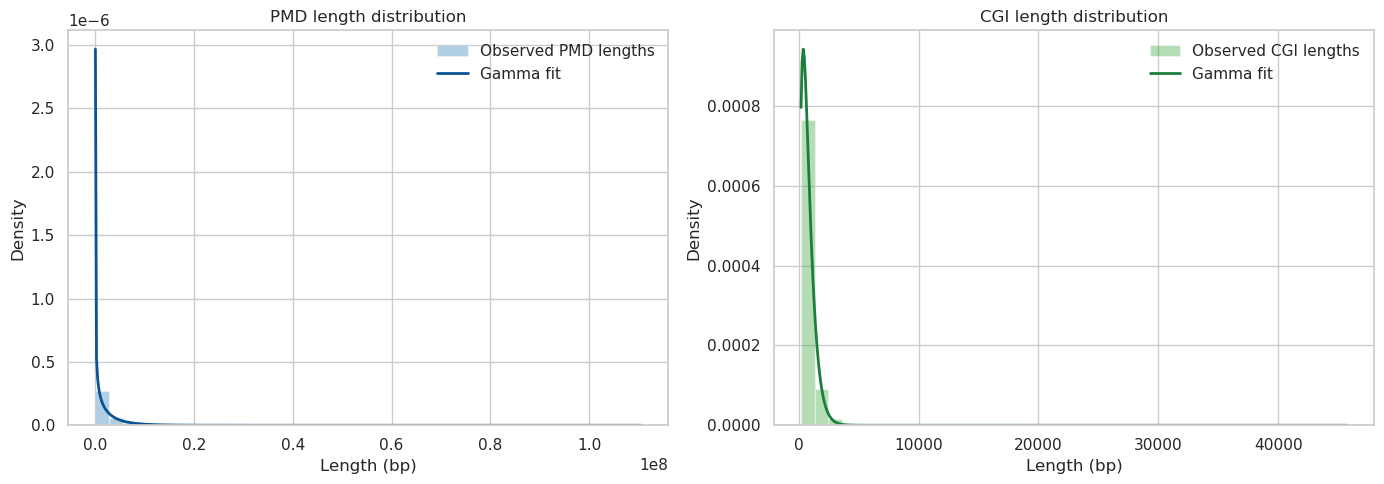

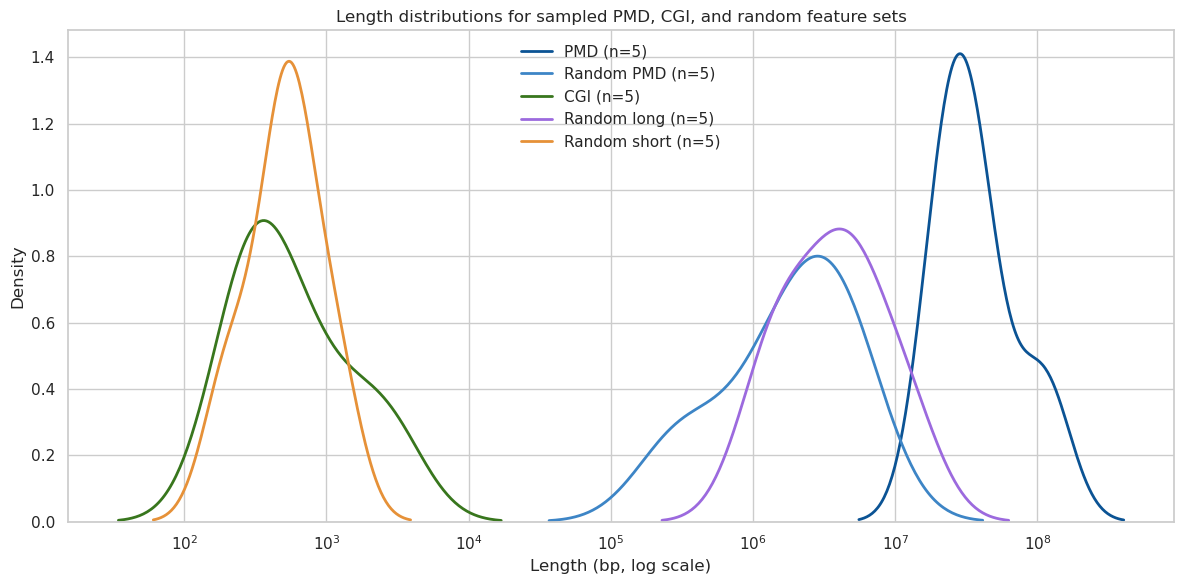

In [74]:
sns.set_theme(style="whitegrid")

pmd_length_distribution = fit_gamma_length_distribution(all_pmds)
cgi_length_distribution = fit_gamma_length_distribution(cgis)

pmd_lengths = _normalize_regions(all_pmds)["length"].to_numpy(dtype=float)
cgi_lengths = _normalize_regions(cgis)["length"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pmd_x = np.linspace(pmd_lengths.min(), pmd_lengths.max(), 500)
axes[0].hist(pmd_lengths, bins=40, density=True, alpha=0.35, color="#1f77b4", label="Observed PMD lengths")
axes[0].plot(
    pmd_x,
    stats.gamma.pdf(
        pmd_x,
        a=pmd_length_distribution["shape"],
        loc=pmd_length_distribution["loc"],
        scale=pmd_length_distribution["scale"],
    ),
    color="#0b5394",
    linewidth=2,
    label="Gamma fit",
)
axes[0].set_title("PMD length distribution")
axes[0].set_xlabel("Length (bp)")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)

cgi_x = np.linspace(cgi_lengths.min(), cgi_lengths.max(), 500)
axes[1].hist(cgi_lengths, bins=40, density=True, alpha=0.35, color="#2ca02c", label="Observed CGI lengths")
axes[1].plot(
    cgi_x,
    stats.gamma.pdf(
        cgi_x,
        a=cgi_length_distribution["shape"],
        loc=cgi_length_distribution["loc"],
        scale=cgi_length_distribution["scale"],
    ),
    color="#1b7f3b",
    linewidth=2,
    label="Gamma fit",
)
axes[1].set_title("CGI length distribution")
axes[1].set_xlabel("Length (bp)")
axes[1].set_ylabel("Density")
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

feature_length_df = pd.concat(
    [
        pd.DataFrame({"feature_set": name, "length": feature_df["length"].to_numpy(dtype=float)})
        for name, feature_df in features.items()
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(12, 6))
feature_palette = {
    "PMD": "#0b5394",
    "Random PMD": "#3d85c6",
    "CGI": "#38761d",
    "Random long": "#9c6ade",
    "Random short": "#e69138",
}

for feature_set, feature_df in feature_length_df.groupby("feature_set", sort=False):
    lengths = feature_df["length"].dropna().astype(float)
    if lengths.empty:
        continue

    color = feature_palette.get(feature_set)
    label = f"{feature_set} (n={len(lengths)})"
    if lengths.nunique() > 1:
        sns.kdeplot(
            x=lengths,
            ax=ax,
            log_scale=True,
            common_norm=False,
            bw_adjust=0.9,
            fill=False,
            linewidth=2,
            color=color,
            label=label,
        )
    else:
        ax.axvline(lengths.iloc[0], color=color, linewidth=2, linestyle="--", label=label)

ax.set_title("Length distributions for sampled PMD, CGI, and random feature sets")
ax.set_xlabel("Length (bp, log scale)")
ax.set_ylabel("Density")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


In [70]:
samples_info

,sample,expression,expression_file,methylation,methylation_file,sample_id,project_id,composition,sample_type,tissue_type,tumor_descriptor,project_descriptor
1017,TCGA-A1-A0SB-01A,36125e17-48fd-4eea-874c-ed2e2e218402.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,e91051ba-d652-4f36-87d3-ad845ae3aedb.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,f66358d4-9319-4c23-983d-ab5056daacf1,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma
1239,TCGA-D8-A73X-01A,1742c1d9-a359-4d9e-b1e4-1d162472e67a.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,04c255a4-cbf9-499b-8172-653d0a3b6070.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,d189e6c5-830e-4624-9df4-cef3301d0fbc,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma
6133,TCGA-A1-A0SK-01A,55d29bdf-c959-4eda-ab2b-e09d7abb58fa.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,c1382633-aefb-47a4-ac46-cf8333ac259b.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,dbd8fda0-bdf2-40f0-80b6-daef5ebf9c97,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma
6134,TCGA-A2-A4S1-01A,1d9d65b8-5af4-40e6-a01f-236f45cfecb4.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,35c66f7d-5cbb-425f-ad01-405a1a27fb17.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,817da1b7-e485-496b-b593-2f8422545c6f,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma
6135,TCGA-EW-A1OW-01A,c8c213fe-4ab7-4671-81cb-fe09b11fcbe7.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,3d141a5a-e774-4031-8877-92252a5ed98a.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,9f55d963-2c1d-4886-980e-edff099babf5,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...
9709,TCGA-E2-A15J-01A,723ed50c-2c78-4a3a-9f6e-9f9e8e264f6b.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,0b7f6506-a464-4635-ae6b-2820a0ab5206.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,6f68a61c-8aec-42d3-b225-22bc6da3e355,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma
9710,TCGA-B6-A40C-01A,32c15b29-da14-4eb5-8c86-39efc94319df.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,f9dd5273-22ef-46c9-a8ad-c501825d2f3e.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,e852c16b-cd36-4551-8cc5-8b59719ca987,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma
9711,TCGA-BH-A0B3-11B,d920c232-82ae-48f9-98d1-b94bf4a45d8d.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,b504445f-170c-44ce-8a84-70db6930397f.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,9a81af95-30f8-45b1-bbda-ca5c7a91c5c5,TCGA-BRCA,Not Reported,Solid Tissue Normal,Not Reported,Not Reported,Breast invasive carcinoma
9712,TCGA-E9-A1QZ-01A,0f168687-6f42-4d92-8f91-13efde785a0c.rna_seq.a...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,a26af0de-1dff-4345-adf2-d3794fd33a6d.methylati...,/uufs/chpc.utah.edu/common/home/u0914269/cleme...,ec76e770-ba6b-4294-a992-993183640ff8,TCGA-BRCA,Not Reported,Primary Tumor,Not Reported,Not Reported,Breast invasive carcinoma


In [71]:
meth_data = load_methylation_data(samples_info)
sample_types = {
    sample: "Normal" if sample_type == "Solid Tissue Normal" else "Tumor"
    for sample, sample_type in zip(
        samples_info["sample"],
        samples_info["sample_type"],
    )
}

In [ ]:
feature_counts = [
    1, 2, 3, 5, 10, 20, 
    # 30, 
    50,
    # 75, 
    100, 
    # 150, 200, 300, 
    500,
    # 750, 
    # 1000,
]

results, sampled_feature_regions = run_feature_classification(
    meth_data=meth_data,
    sample_types=sample_types,
    pmds_per_sample=pmds_per_sample,
    cgis=cgis,
    feature_counts=feature_counts,
    n_splits=5,
    n_repeats=10,
    n_feature_draws=10,
    random_seed=RANDOM_SEED,
)

CV splits:   0%|          | 0/50 [00:00<?, ?it/s]

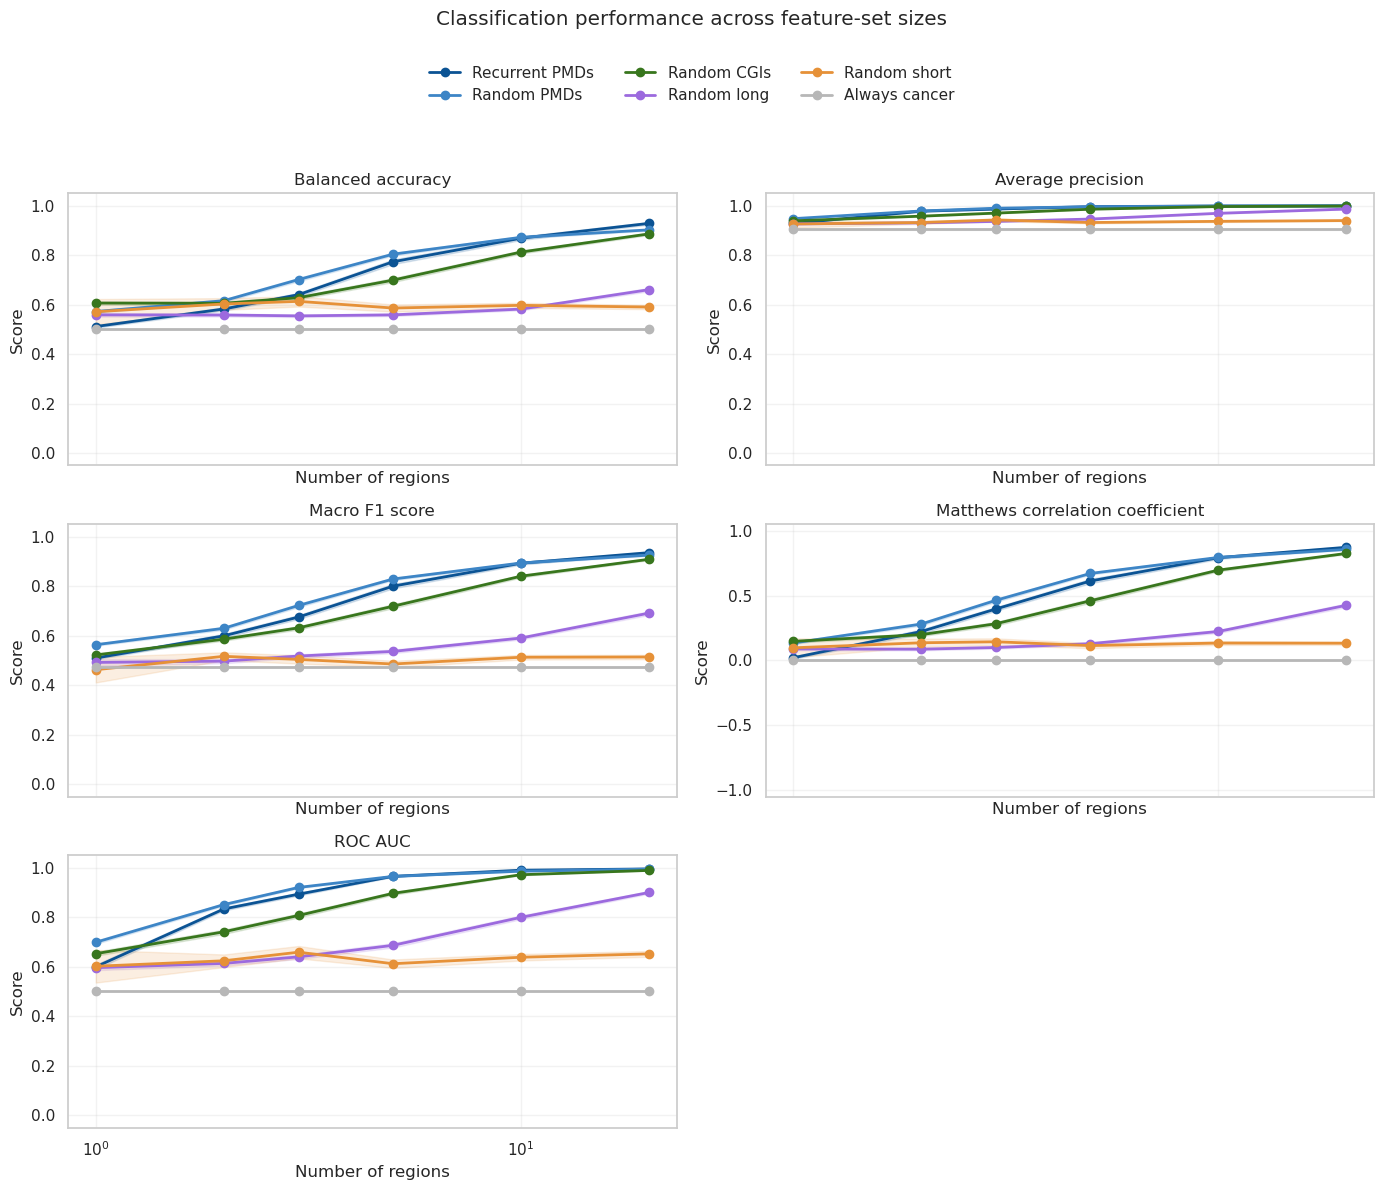

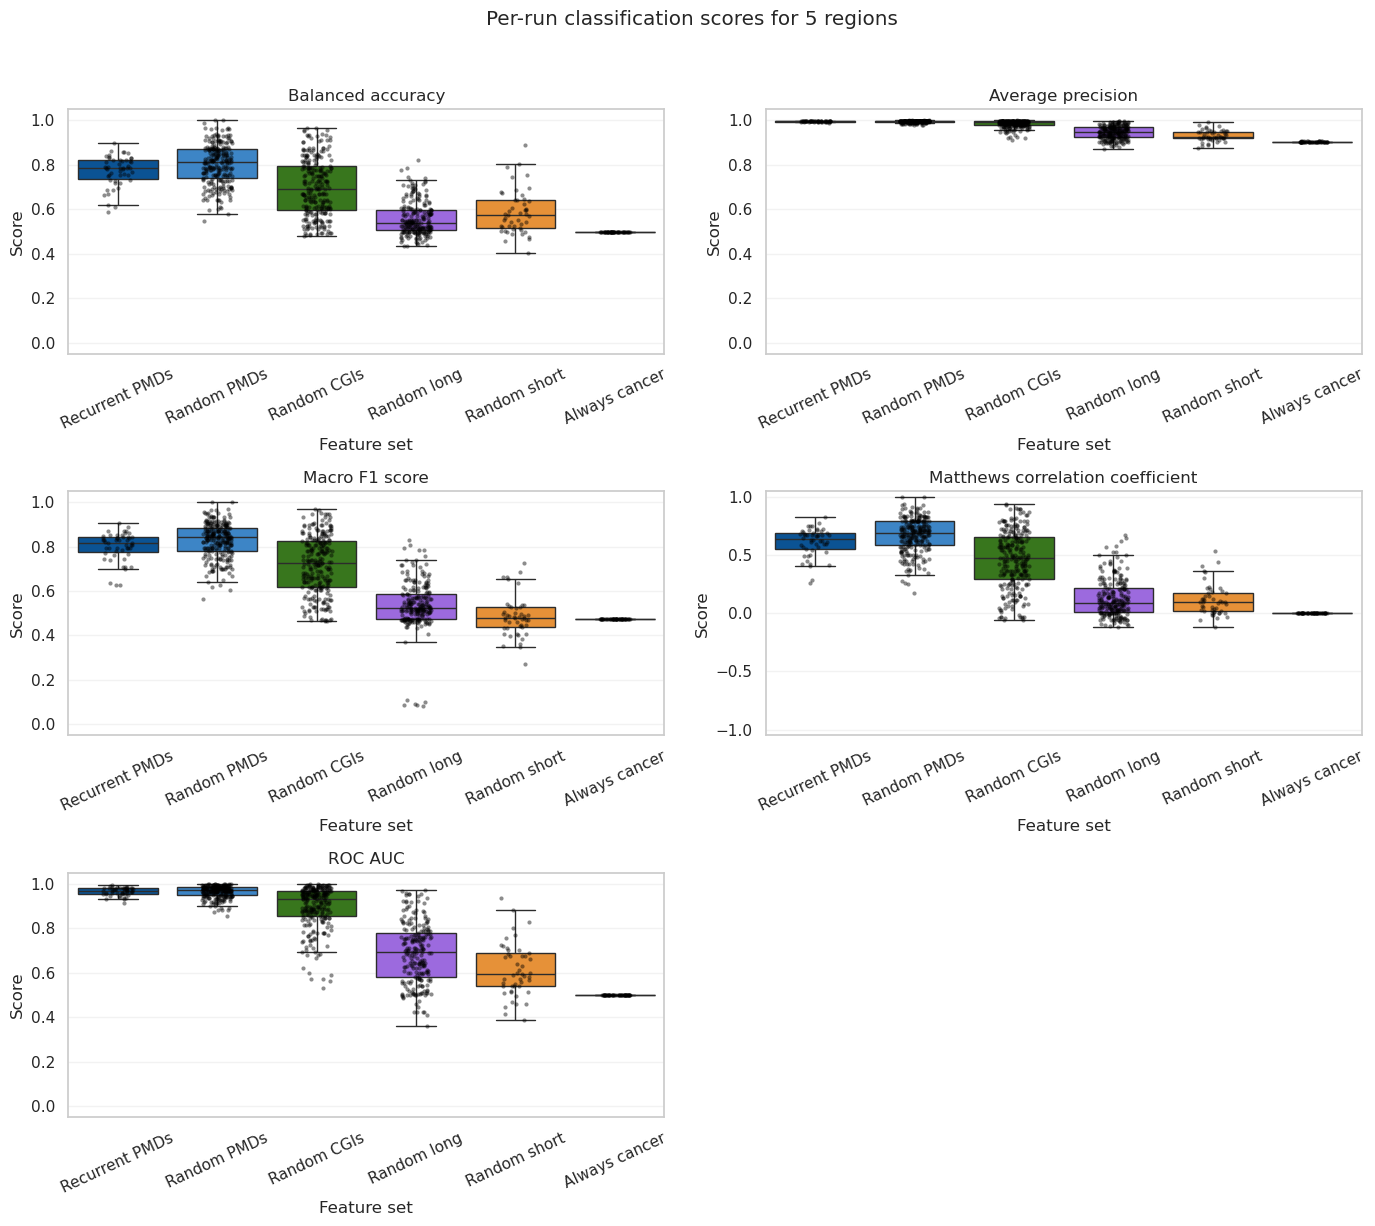

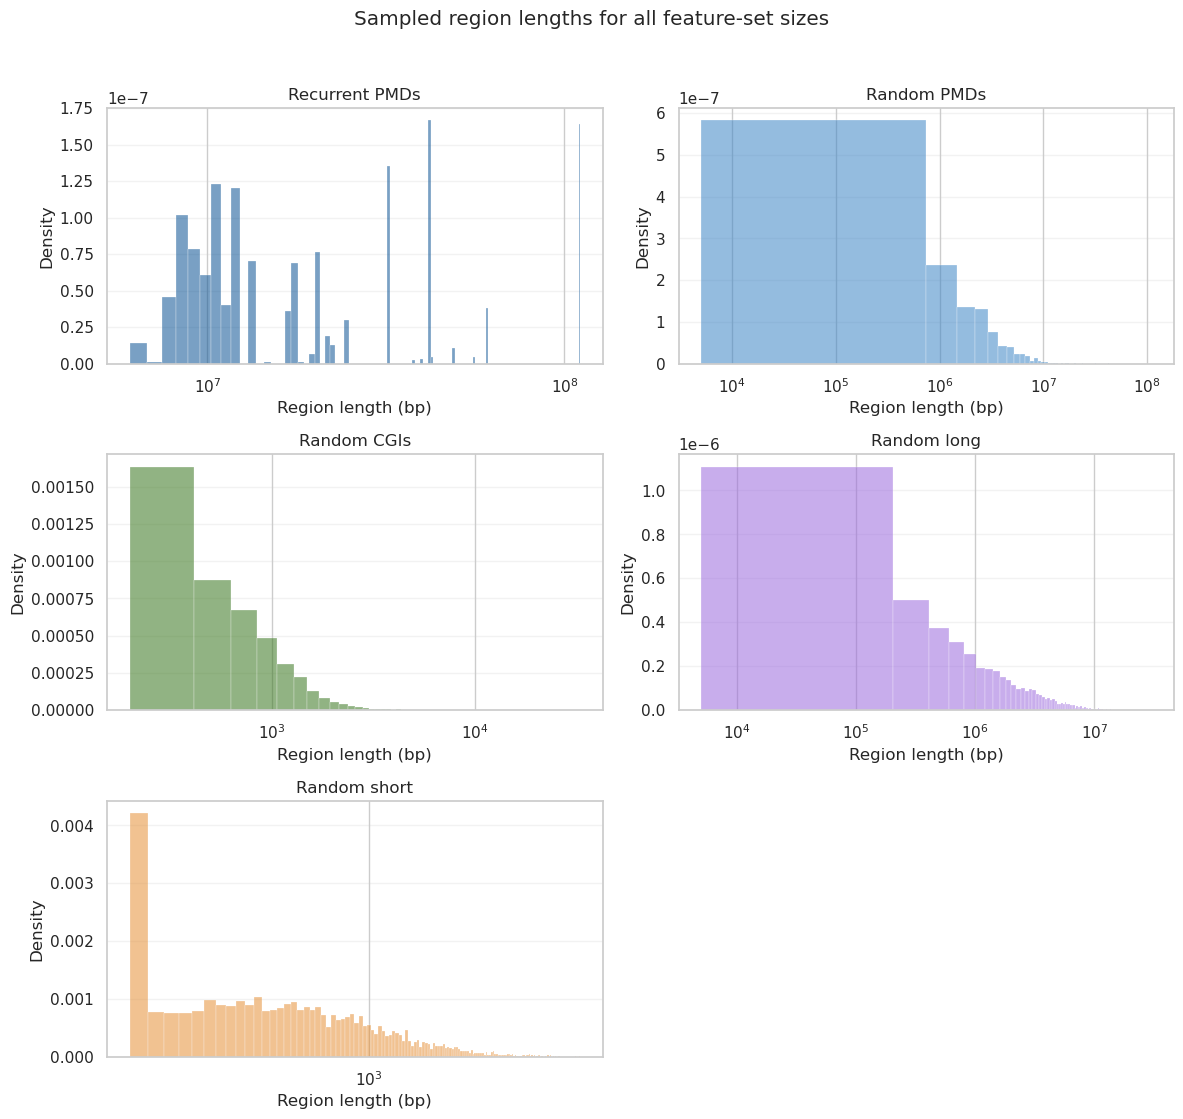

,index,feature_set,n_features,metric,mean,std,n_runs,sem
0,0,Always cancer,1,average_precision,0.90411,0.002263,50,0.000320
1,1,Always cancer,1,balanced_accuracy,0.50000,0.000000,50,0.000000
2,2,Always cancer,1,macro_f1,0.47482,0.000623,50,0.000088
3,3,Always cancer,1,mcc,0.00000,0.000000,50,0.000000
4,4,Always cancer,1,roc_auc,0.50000,0.000000,50,0.000000
5,5,Always cancer,2,average_precision,0.90411,0.002263,50,0.000320
6,6,Always cancer,2,balanced_accuracy,0.50000,0.000000,50,0.000000
7,7,Always cancer,2,macro_f1,0.47482,0.000623,50,0.000088
8,8,Always cancer,2,mcc,0.00000,0.000000,50,0.000000
9,9,Always cancer,2,roc_auc,0.50000,0.000000,50,0.000000


In [ ]:
X_LOG_SCALE = False

classification_summary = plot_classification_results(results, x_log_scale=X_LOG_SCALE)
classification_box_data = plot_classification_box_results(results, n_features=5)
classification_length_data = plot_sampled_feature_length_distributions(
    sampled_feature_regions,
    n_features=None,
)
classification_summary.head(10)
